# Tutorial 1: Quick-start tutorial

**The orientation tutorial.** Read this first if you've never used AmorphGen.

By the end you will:
1. Know **what** AmorphGen does (and what it doesn't).
2. Have generated and relaxed **one amorphous structure** end-to-end.
3. Know which of the **three workflows** (random, melt-quench, hybrid) to use for your problem.
4. Know **which deeper tutorial** to open next.

**Wall time**: a few minutes of reading; the live demo cell runs in well under a minute on a typical laptop CPU (faster on GPU; specific timing depends on your hardware and the backend you have installed).

**Requires**: AmorphGen + CHGNet backend (`pip install amorphgen chgnet`).

## What is AmorphGen?

AmorphGen generates **realistic atomic-scale models of amorphous materials** (oxides, halides, alloys, glasses) using machine-learning interatomic potentials. It exists because:

- **Amorphous materials are everywhere** in technology (thin-film transistors, TCOs, memristors, battery anodes), but they're hard to model from first principles.
- **DFT melt-quench is the gold standard** but is limited to ~200 atoms / ~100 ps. Extending to larger systems or more compositions is impractical.
- **Universal MLIPs** (MACE, CHGNet, SevenNet) make MLIP melt-quench cheap enough to do across many compositions.

AmorphGen wraps the assembly: a single command takes you from "composition" or "crystal CIF" to "amorphous structure ready for property prediction" with DFT.

## The three workflows

AmorphGen offers three routes from composition (or crystal) to amorphous structure. They differ in computational cost, defensibility, and what input you have:

| Workflow | Input | What it does | Relative cost | When to use |
|---|---|---|---|---|
| **Random + relax** | composition | Place atoms randomly with smart minsep, then MLIP-relax | **Cheapest** — single relaxation only | Quick screening, novel chemistries, generating large ensembles |
| **Full melt-quench** | crystal structure | 7-stage MD: opt → premelt → heat → eq-high → quench → eq-low → final-opt | **Most expensive** — long MD runs across all stages | Reproducing DFT melt-quench protocols, defending against published references |
| **Hybrid** | composition | Random + skip-the-heating: anneal at high T → quench → eq → opt | **Medium** — skips the heat ramp; random input is already disordered | Production ensembles when starting from disordered structures is acceptable |

**What actually determines wall time** for any of these workflows:
- **System size** — MLIP cost grows roughly linearly to quadratically with atom count
- **Hardware** — a CUDA GPU is typically 10–50× faster than CPU for the same MLIP
- **MD durations** — longer equilibration / slower heat & cool ramps = better-converged structures, more compute


**Decision tree**:
- Need to compare against published DFT melt-quench? → **Full melt-quench** (Tutorial 4)
- Need many structures fast? → **Hybrid** (Tutorial 5) or **Random + relax** (Tutorials 2 / 3)
- Just exploring a new chemistry? → **Random + relax** (Tutorial 2 — start here)

All three workflows can use any supported backend (MACE, CHGNet, SevenNet, classical Buckingham/LJ).

## Demo: random + relax on a-SiO₂

The random placement followed by a short MLIP relaxation. On CPU this tutorial was validated on, the cells below take well under a minute end-to-end. **The other two workflows (full melt-quench, hybrid) have the same API style but run many MD stages** (uncomment to run on your hardware).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from amorphgen import generate_random
from amorphgen.utils import get_calculator
from ase.optimize import LBFGS

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
print("Imports complete.")

Imports complete.


In [2]:
# Step 1: random placement.
# Composition is the only required input — minsep, density, target CN are
# all auto-derived from Shannon ionic radii + material classification.
atoms = generate_random(composition={"Si": 8, "O": 16}, seed=42)

print(f"Generated:  {atoms.get_chemical_formula()}")
print(f"  Atoms:    {len(atoms)}")
print(f"  Cell:     {atoms.cell.lengths()[0]:.2f} Å (cubic)")
print(f"  Auto-derived everything — no minsep/density/CN supplied by user.")

Generated:  O16Si8
  Atoms:    24
  Cell:     7.19 Å (cubic)
  Auto-derived everything — no minsep/density/CN supplied by user.


In [3]:
# Step 2: MLIP relaxation with CHGNet (fast on CPU).
calc = get_calculator("chgnet", device="cpu")
atoms.calc = calc

opt = LBFGS(atoms, logfile=None)
opt.run(fmax=0.1, steps=100)

e_per_atom = atoms.get_potential_energy() / len(atoms)
print(f"Relaxed:   E/atom = {e_per_atom:.3f} eV  (after {opt.nsteps} LBFGS steps)")

[CHGNet] Loading pretrained model on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet will run on cpu


/Users/c.kaewmeechai@bham.ac.uk/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)


Relaxed:   E/atom = -8.071 eV  (after 100 LBFGS steps)


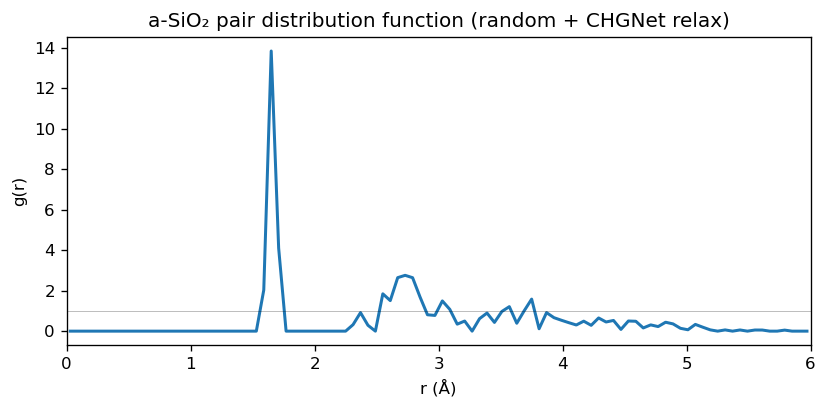

  First peak near 1.6 Å is the Si–O bond.
  First minimum near 2.1 Å separates first- from second-neighbour shells.


In [4]:
# Step 3: structural analysis — pair distribution function g(r).
def total_gr(atoms, r_max=6.0, n_bins=100):
    pos = atoms.get_positions()
    L = atoms.cell.lengths()[0]
    n = len(pos)
    rho = n / atoms.get_volume()
    edges = np.linspace(0, r_max, n_bins + 1)
    counts = np.zeros(n_bins)
    for i in range(n):
        d = pos - pos[i]
        d -= L * np.round(d / L)
        r = np.linalg.norm(d, axis=1)
        r = r[(r > 0) & (r < r_max)]
        counts += np.histogram(r, bins=edges)[0]
    shell_v = (4/3) * np.pi * (edges[1:]**3 - edges[:-1]**3)
    g = counts / (n * rho * shell_v)
    return 0.5 * (edges[:-1] + edges[1:]), g

r, g = total_gr(atoms)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(r, g, lw=1.8)
ax.axhline(1.0, color="k", lw=0.5, alpha=0.3)
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_title("a-SiO₂ pair distribution function (random + CHGNet relax)")
ax.set_xlim(0, 6)
fig.tight_layout()
plt.show()

print("  First peak near 1.6 Å is the Si–O bond.")
print("  First minimum near 2.1 Å separates first- from second-neighbour shells.")

## Save the relaxed structure

The `atoms` object so far lives only in memory. Save it in three formats so you can open it in your visualiser of choice (OVITO, VESTA, jmol, etc.) or feed it to other ASE-based analysis tools later.

In [5]:
from ase.io import write
from pathlib import Path

out_dir = Path('output_T1')
out_dir.mkdir(exist_ok=True)

write(out_dir / 'amorphous_SiO2.xyz', atoms, format='extxyz')  # extxyz: cell + PBC + energies
write(out_dir / 'amorphous_SiO2.vasp', atoms, format='vasp', sort=True)  # POSCAR
write(out_dir / 'amorphous_SiO2.cif', atoms)                  # CIF for visualisers

print(f'Saved relaxed a-SiO\u2082 to {out_dir.resolve()}/:')
for f in sorted(out_dir.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size} bytes)')

Saved relaxed a-SiO₂ to /Users/c.kaewmeechai@bham.ac.uk/Bask_backup/AmorphGen/Tutorials/T1_5min_intro/output_T1/:
  amorphous_SiO2.cif  (2744 bytes)
  amorphous_SiO2.vasp  (1722 bytes)
  amorphous_SiO2.xyz  (3505 bytes)


**That's it.** You generated and relaxed an amorphous structure with five lines of code. The output `atoms` is a standard ASE `Atoms` object — pass it to any property-prediction tool from here.

For an ensemble of 20 a-SiO₂ structures with the same workflow, replace step 1 with:

```bash
amorphgen --random-gen --composition "SiO2*8" -n 20 \
    --relax --model chgnet --device cpu --format vasp -o random_SiO2/
```

That's the **production-grade equivalent** of the live demo above.

## Workflow 2: Full melt-quench (code preview)

Use this when you need to defend against published DFT melt-quench protocols. The full pipeline runs many MD stages — wall time depends on system size, hardware, and the MD durations you choose in the YAML. On a single GPU this is typically the workflow you'd run for a single careful structure; on CPU it's the slowest of the three and benefits most from running on HPC.

**Tutorial 4** runs this end-to-end on crystalline SiO₂; here is just the API shape:

In [6]:
# Workflow 2 — full melt-quench (NOT executed in this tutorial)
#
# from amorphgen import MeltQuenchPipeline
# pipe = MeltQuenchPipeline(
#     input_file="SiO2_supercell.xyz",   # crystal structure as input
#     work_dir="SiO2_mq",
#     cfg_override={
#         "model": "chgnet", "device": "cpu",
#         "melt": {"T_end": 3000},        # all 7 stages have YAML-style overrides
#     },
# )
# final_atoms = pipe.run()                 # blocks until all 7 stages complete
#
# Equivalent CLI:
# amorphgen SiO2_supercell.xyz --model chgnet --device cpu -o SiO2_mq/

print("See Tutorial 4 (T4_MQ_via_7_steps) for the full melt-quench example.")

See Tutorial 4 (T4_MQ_via_7_steps) for the full melt-quench example.


## Workflow 3: Hybrid (code preview)

Use this for production ensembles when you don't have a crystalline input or don't need to match a specific DFT protocol. Generates random structures and skips the heating ramp by jumping straight to high-T equilibration. Per-snapshot cost is between random+relax and full melt-quench — the exact wall time depends on system size, the equilibration duration you pick, and the backend / hardware.

**Tutorial 5** runs this end-to-end on TiO₂; here is just the CLI:

In [7]:
# Workflow 3 — hybrid ensemble (NOT executed in this tutorial)
#
# # Step 1: ensemble of N random starting structures
# # amorphgen --random-gen --composition "SiO2*8" -n 20 \
# #     --relax --model chgnet --device cpu -o random_SiO2/
#
# # Step 2: hybrid pipeline (stages 4-5-6-7) on each input
# # amorphgen --hybrid-ensemble --input-dir random_SiO2/ \
# #     --config hybrid.yaml --device cpu --model chgnet -o sio2_hybrid/

print("See Tutorial 5 (T5_mix_random_MQ) for the full hybrid example.")
print("See docs/guides/hybrid-workflow.md for the recommended hybrid YAML config.")

See Tutorial 5 (T5_mix_random_MQ) for the full hybrid example.
See docs/guides/hybrid-workflow.md for the recommended hybrid YAML config.


## When to use which workflow — quick recap

| Situation | Use | Tutorial |
|---|---|---|
| First exposure to AmorphGen | random + relax | **T2** (zero-config) → **T1** (advanced) |
| Match a published DFT melt-quench | full melt-quench | **T2** |
| Generate a 20–100 structure ensemble | hybrid | **T3** |
| Single-element covalent (a-Si, a-Ge) | random + repair | **T1** with `--repair-iters` |
| No GPU, no MLIP install | classical potentials | **T4** |
| Investigate a specific defect | random + targeted minsep | **T5** (peroxide-defect case study) |

All workflows accept the same `--composition`, `--target-density`, `--target-cn`, and `--config YAML` options — the difference is the orchestration around the underlying placement + relax + MD primitives.

## Where to go next

- **{doc}`/tutorials/index`** — full tutorial list with backends and systems.
- **{doc}`/guides/random-generation`** — random-gen guide with auto-derivation tables.
- **{doc}`/guides/pipeline`** — 7-stage pipeline architecture.
- **{doc}`/guides/hybrid-workflow`** — when to pick hybrid over full MQ.
- **{doc}`/guides/backends`** — choosing between MACE / CHGNet / SevenNet / classical.
- **{doc}`/api/random-gen`** — full Python API reference for `generate_random` and `batch_random`.

If you got here from the README, the natural next step is **Tutorial 2** (zero-config random gen across 7 material classes).